In [1]:
# Cell 1 — Load + Integrity + Freeze Analysis
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Patch
from scipy.stats import rankdata, spearmanr, wilcoxon


def find_repo_root(start):
    """Find the repository root from any notebook working directory."""
    for path in (start, *start.parents):
        if (path / "phase1" / "results").is_dir():
            return path
    raise FileNotFoundError("Repository root was not found.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
INPUT_DIR = REPO_ROOT / "phase1" / "results" / "lle" / "processed"
EXPECTED_SESSIONS = (1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 21, 22, 23, 25)
PRIMARY_DURATION = 60
ROBUSTNESS_DURATIONS = (120, 180)
ALL_DURATIONS = (PRIMARY_DURATION, *ROBUSTNESS_DURATIONS)
STATE_ORDER = ("Awake", "Drowsy")
DELTA_DEFINITION = "Drowsy - Awake"
BOOTSTRAP_RESAMPLES = 20_000
BOOTSTRAP_SEED = 2026
STRICT_R2_THRESHOLD = 0.95
ZERO_TOLERANCE = 1e-12
COLORS = {"Awake": "#0072B2", "Drowsy": "#D55E00"}

session_paths = sorted(INPUT_DIR.glob("session_*_processed_rosenstein_lle.csv"))
if not session_paths:
    raise FileNotFoundError(f"No per-session LLE CSVs found in {INPUT_DIR}")

frames = []
for path in session_paths:
    frame = pd.read_csv(path)
    frames.append(frame)
all_rows = pd.concat(frames, ignore_index=True)

required_columns = {
    "session", "window_id", "state", "window_size_s",
    "representation", "lle_1_per_s", "fit_r2", "theiler_s",
    "n_pairs_fit_min", "analysis_included", "valid", "qc_reason",
}
missing_columns = required_columns.difference(all_rows.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

assert set(all_rows["session"].unique()) == set(EXPECTED_SESSIONS)
assert len(session_paths) == len(EXPECTED_SESSIONS)
assert (all_rows["representation"] == "processed").all()
assert all_rows["analysis_included"].astype(bool).all()
assert all_rows["state"].isin(STATE_ORDER).all()
assert all_rows["window_size_s"].isin(ALL_DURATIONS).all()
assert not all_rows.duplicated(
    ["session", "window_size_s", "state", "window_id"]
).any()

qc_failure_count = int((~all_rows["valid"].astype(bool)).sum())
analysis = all_rows[
    all_rows["valid"].astype(bool)
    & np.isfinite(all_rows["lle_1_per_s"])
].copy()
assert np.isfinite(analysis["lle_1_per_s"]).all()

integrity_summary = pd.Series({
    "sessions": analysis["session"].nunique(),
    "all_included_windows": len(all_rows),
    "valid_windows": len(analysis),
    "Awake_valid_windows": int((analysis["state"] == "Awake").sum()),
    "Drowsy_valid_windows": int((analysis["state"] == "Drowsy").sum()),
    "QC_failures": qc_failure_count,
    "LLE_min": analysis["lle_1_per_s"].min(),
    "LLE_max": analysis["lle_1_per_s"].max(),
    "fit_R2_median": analysis["fit_r2"].median(),
    "fit_R2_Q1": analysis["fit_r2"].quantile(0.25),
    "fit_R2_Q3": analysis["fit_r2"].quantile(0.75),
}, name="value")
duration_counts = analysis.groupby(["window_size_s", "state"]).size().rename("n_valid").to_frame()

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})
print(f"Input directory: {INPUT_DIR}")
print(f"Primary: {PRIMARY_DURATION} s session-level paired contrast ({DELTA_DEFINITION})")
display(integrity_summary.to_frame())
display(duration_counts)

Input directory: /home/vutu0809/Desktop/NTSA_Foundation/phase1/results/lle/processed
Primary: 60 s session-level paired contrast (Drowsy - Awake)


,value
sessions,20.000000
all_included_windows,1544.000000
valid_windows,1508.000000
Awake_valid_windows,1003.000000
Drowsy_valid_windows,505.000000
QC_failures,36.000000
LLE_min,0.561407
LLE_max,1.081865
fit_R2_median,0.975948
fit_R2_Q1,0.961037


n_valid
window_size_s state          
60            Awake       579
              Drowsy      293
120           Awake       264
              Drowsy      135
180           Awake       160
              Drowsy       77

,window_size_s,state,n,median,Q1,Q3,IQR
0,60,Awake,579,0.81563,0.75439,0.87551,0.12112
1,60,Drowsy,293,0.77971,0.72627,0.83589,0.10962
2,120,Awake,264,0.84587,0.79567,0.90646,0.11079
3,120,Drowsy,135,0.80303,0.74280,0.85325,0.11045
4,180,Awake,160,0.85605,0.81687,0.90697,0.09011
5,180,Drowsy,77,0.82431,0.76453,0.86573,0.10120


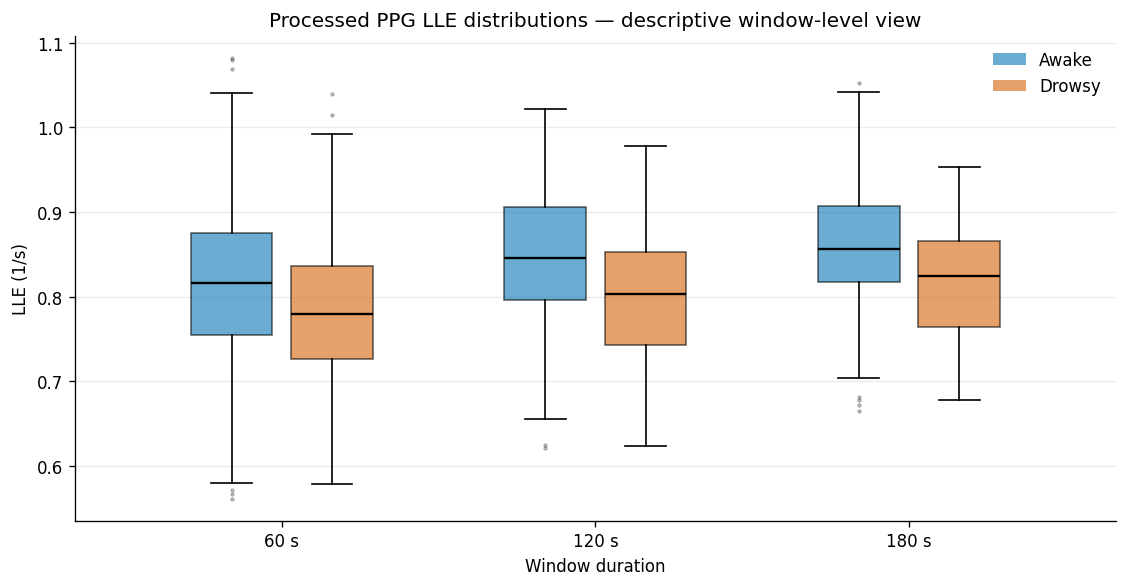

In [2]:
# Cell 2 — Window-Level Descriptive Overview (no window-level inference)
window_descriptive = (
    analysis.groupby(["window_size_s", "state"])["lle_1_per_s"]
    .agg(
        n="size",
        median="median",
        Q1=lambda values: values.quantile(0.25),
        Q3=lambda values: values.quantile(0.75),
    )
    .reset_index()
)
window_descriptive["IQR"] = window_descriptive["Q3"] - window_descriptive["Q1"]
display(window_descriptive.round(5))

fig, ax = plt.subplots(figsize=(9.5, 5.0))
offsets = {"Awake": -0.16, "Drowsy": 0.16}
for duration_index, duration_s in enumerate(ALL_DURATIONS):
    for state in STATE_ORDER:
        values = analysis.loc[
            (analysis["window_size_s"] == duration_s)
            & (analysis["state"] == state),
            "lle_1_per_s",
        ].to_numpy()
        box = ax.boxplot(
            values, positions=[duration_index + offsets[state]], widths=0.26,
            patch_artist=True, showfliers=True,
            medianprops={"color": "black", "linewidth": 1.4},
            flierprops={"marker": ".", "markersize": 3, "alpha": 0.35},
        )
        box["boxes"][0].set(facecolor=COLORS[state], alpha=0.58)

ax.set(
    xticks=range(len(ALL_DURATIONS)),
    xticklabels=[f"{duration} s" for duration in ALL_DURATIONS],
    xlabel="Window duration", ylabel="LLE (1/s)",
    title="Processed PPG LLE distributions — descriptive window-level view",
)
ax.legend(
    handles=[Patch(facecolor=COLORS[state], alpha=0.58, label=state) for state in STATE_ORDER],
    frameon=False,
)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

In [3]:
# Cell 3 — Session-Level Awake–Drowsy Contrasts
def build_session_contrasts(window_frame):
    """Aggregate windows by session/state and retain paired states only."""
    session_state = (
        window_frame.groupby(["session", "window_size_s", "state"], as_index=False)
        .agg(
            median_lle=("lle_1_per_s", "median"),
            n_windows=("lle_1_per_s", "size"),
            median_fit_r2=("fit_r2", "median"),
            median_theiler_s=("theiler_s", "median"),
            min_pairs_fit=("n_pairs_fit_min", "min"),
        )
    )
    awake = session_state[session_state["state"] == "Awake"].drop(columns="state").rename(columns={
        "median_lle": "awake_median", "n_windows": "n_awake",
        "median_fit_r2": "awake_fit_r2_median",
        "median_theiler_s": "awake_theiler_median",
        "min_pairs_fit": "awake_pairs_fit_min",
    })
    drowsy = session_state[session_state["state"] == "Drowsy"].drop(columns="state").rename(columns={
        "median_lle": "drowsy_median", "n_windows": "n_drowsy",
        "median_fit_r2": "drowsy_fit_r2_median",
        "median_theiler_s": "drowsy_theiler_median",
        "min_pairs_fit": "drowsy_pairs_fit_min",
    })
    paired = awake.merge(drowsy, on=["session", "window_size_s"], how="inner")
    paired["delta"] = paired["drowsy_median"] - paired["awake_median"]
    paired["session_fit_r2"] = paired[["awake_fit_r2_median", "drowsy_fit_r2_median"]].min(axis=1)
    return session_state, paired.sort_values(["window_size_s", "session"]).reset_index(drop=True)


session_state, paired_contrasts = build_session_contrasts(analysis)
contrast_table = paired_contrasts[[
    "session", "window_size_s", "awake_median", "drowsy_median",
    "delta", "n_awake", "n_drowsy",
]].rename(columns={"window_size_s": "duration"})

contrast_descriptive_rows = []
for duration_s in ALL_DURATIONS:
    deltas = paired_contrasts.loc[
        paired_contrasts["window_size_s"] == duration_s, "delta"
    ].to_numpy()
    contrast_descriptive_rows.append({
        "duration": duration_s,
        "paired_sessions": deltas.size,
        "median_delta": np.median(deltas),
        "delta_Q1": np.quantile(deltas, 0.25),
        "delta_Q3": np.quantile(deltas, 0.75),
        "negative_sessions": int(np.sum(deltas < -ZERO_TOLERANCE)),
        "positive_sessions": int(np.sum(deltas > ZERO_TOLERANCE)),
        "zero_sessions": int(np.sum(np.isclose(deltas, 0.0, atol=ZERO_TOLERANCE))),
    })
contrast_descriptive = pd.DataFrame(contrast_descriptive_rows)
display(contrast_table.round(5))
display(contrast_descriptive.round(5))
print("Delta < 0: Drowsy has lower local trajectory divergence.")
print("Delta > 0: Drowsy has higher local trajectory divergence.")

,session,duration,awake_median,drowsy_median,delta,n_awake,n_drowsy
0,1,60,0.93638,0.85085,-0.08554,24,7
1,4,60,0.80820,0.75885,-0.04935,29,17
2,5,60,0.76288,0.69413,-0.06875,33,16
3,6,60,0.82569,0.80464,-0.02105,30,17
4,7,60,0.85738,0.80435,-0.05303,34,10
5,8,60,0.85320,0.81263,-0.04058,36,10
6,9,60,0.75387,0.76184,0.00797,40,17
7,10,60,0.89067,0.82944,-0.06123,27,9
8,11,60,0.84377,0.81887,-0.02490,19,18
9,12,60,0.76974,0.77286,0.00312,20,33


,duration,paired_sessions,median_delta,delta_Q1,delta_Q3,negative_sessions,positive_sessions,zero_sessions
0,60,20,-0.03757,-0.05608,-0.01678,16,4,0
1,120,20,-0.04421,-0.07108,-0.01893,18,2,0
2,180,20,-0.04985,-0.06156,-0.00981,16,4,0


Delta < 0: Drowsy has lower local trajectory divergence.
Delta > 0: Drowsy has higher local trajectory divergence.


In [4]:
# Cell 4 — Primary Session-Level Inference (60 s only)
def bootstrap_median_ci(values, n_resamples=BOOTSTRAP_RESAMPLES, seed=BOOTSTRAP_SEED):
    """Return a session-resampled percentile CI for the median."""
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, values.size, size=(n_resamples, values.size))
    bootstrap_medians = np.median(values[indices], axis=1)
    return tuple(np.quantile(bootstrap_medians, [0.025, 0.975]))


def matched_rank_biserial(deltas):
    """Compute signed matched-pairs rank-biserial correlation."""
    deltas = np.asarray(deltas, dtype=float)
    nonzero = deltas[~np.isclose(deltas, 0.0, atol=ZERO_TOLERANCE)]
    if nonzero.size == 0:
        return 0.0
    ranks = rankdata(np.abs(nonzero), method="average")
    positive_rank_sum = ranks[nonzero > 0].sum()
    negative_rank_sum = ranks[nonzero < 0].sum()
    return float(
        (positive_rank_sum - negative_rank_sum)
        / (positive_rank_sum + negative_rank_sum)
    )


def analyze_session_deltas(deltas, duration_s, seed=BOOTSTRAP_SEED):
    """Apply the frozen session-level analysis to one duration."""
    deltas = np.asarray(deltas, dtype=float)
    ci_low, ci_high = bootstrap_median_ci(deltas, seed=seed)
    test = wilcoxon(
        deltas, zero_method="wilcox", alternative="two-sided", method="auto"
    )
    return {
        "duration_s": duration_s,
        "paired_sessions": deltas.size,
        "median_delta": np.median(deltas),
        "ci_95_low": ci_low,
        "ci_95_high": ci_high,
        "wilcoxon_statistic": float(test.statistic),
        "p_value": float(test.pvalue),
        "rank_biserial": matched_rank_biserial(deltas),
        "drowsy_lower": int(np.sum(deltas < -ZERO_TOLERANCE)),
        "drowsy_higher": int(np.sum(deltas > ZERO_TOLERANCE)),
        "zero": int(np.sum(np.isclose(deltas, 0.0, atol=ZERO_TOLERANCE))),
    }


primary_pairs = paired_contrasts[paired_contrasts["window_size_s"] == PRIMARY_DURATION]
primary_result = analyze_session_deltas(
    primary_pairs["delta"].to_numpy(), PRIMARY_DURATION
)
primary_result["awake_session_median"] = primary_pairs["awake_median"].median()
primary_result["drowsy_session_median"] = primary_pairs["drowsy_median"].median()
primary_table = pd.DataFrame([primary_result])
display(primary_table.round(6))
print("H0: the session-level paired Awake–Drowsy LLE difference is centered at zero.")

,duration_s,paired_sessions,median_delta,ci_95_low,ci_95_high,wilcoxon_statistic,p_value,rank_biserial,drowsy_lower,drowsy_higher,zero,awake_session_median,drowsy_session_median
0,60,20,-0.03757,-0.053698,-0.022976,20.0,0.000708,-0.809524,16,4,0,0.810912,0.794717


H0: the session-level paired Awake–Drowsy LLE difference is centered at zero.


In [5]:
# Cell 5 — Window-Size Robustness
robustness_rows = []
for duration_s in ALL_DURATIONS:
    deltas = paired_contrasts.loc[
        paired_contrasts["window_size_s"] == duration_s, "delta"
    ].to_numpy()
    row = analyze_session_deltas(deltas, duration_s)
    row["drowsy_lower_fraction"] = row["drowsy_lower"] / row["paired_sessions"]
    robustness_rows.append(row)

robustness_table = pd.DataFrame(robustness_rows)
display(robustness_table[[
    "duration_s", "paired_sessions", "median_delta",
    "ci_95_low", "ci_95_high", "p_value", "rank_biserial",
    "drowsy_lower", "drowsy_lower_fraction",
]].round(6))
print("Primary emphasis remains the 60-s contrast; 120/180 s are robustness analyses.")

,duration_s,paired_sessions,median_delta,ci_95_low,ci_95_high,p_value,rank_biserial,drowsy_lower,drowsy_lower_fraction
0,60,20,-0.037570,-0.053698,-0.022976,0.000708,-0.809524,16,0.8
1,120,20,-0.044214,-0.059098,-0.021612,0.002325,-0.742857,18,0.9
2,180,20,-0.049850,-0.058397,-0.021318,0.000586,-0.819048,16,0.8


Primary emphasis remains the 60-s contrast; 120/180 s are robustness analyses.


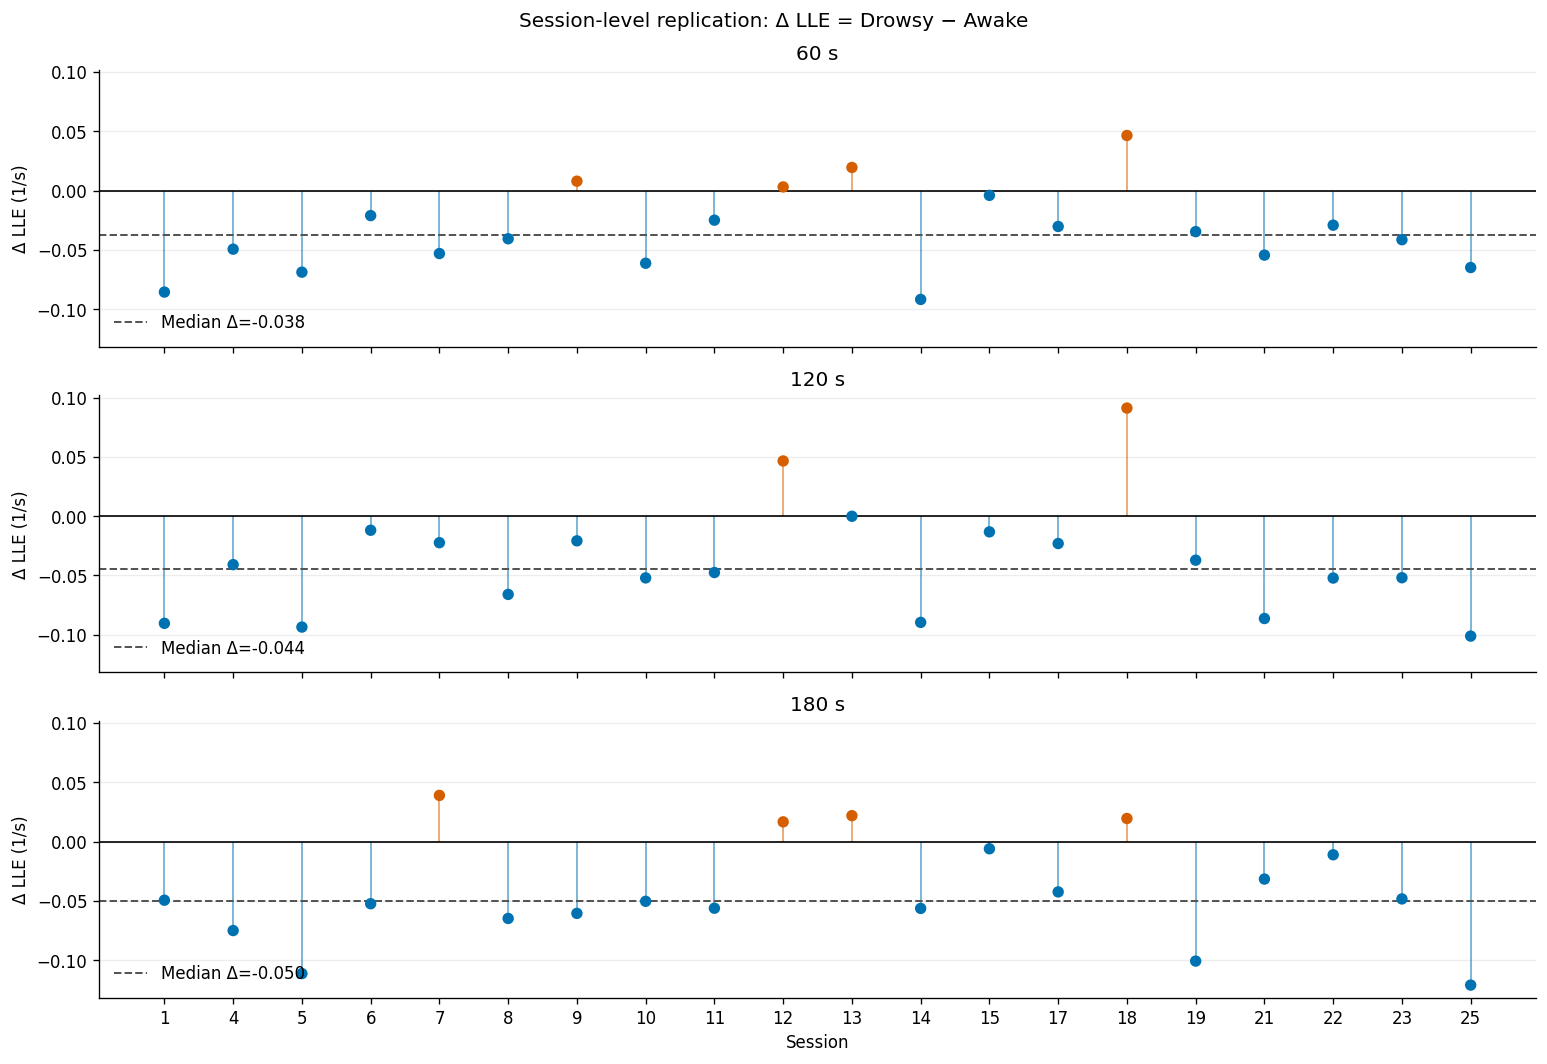

In [6]:
# Cell 6 — Cross-Session Replication Figure
session_order = list(EXPECTED_SESSIONS)
x_lookup = {session: index for index, session in enumerate(session_order)}
fig, axes = plt.subplots(3, 1, figsize=(13.0, 9.0), sharex=True, sharey=True)

for ax, duration_s in zip(axes, ALL_DURATIONS):
    subset = paired_contrasts[paired_contrasts["window_size_s"] == duration_s]
    x = np.array([x_lookup[session] for session in subset["session"]])
    y = subset["delta"].to_numpy()
    point_colors = np.where(y < 0.0, "#0072B2", "#D55E00")
    ax.vlines(x, 0.0, y, color=point_colors, alpha=0.55, linewidth=1.1)
    ax.scatter(x, y, c=point_colors, s=34, zorder=3)
    ax.axhline(0.0, color="black", linewidth=1.0)
    ax.axhline(
        np.median(y), color="#555555", linestyle="--", linewidth=1.2,
        label=f"Median Δ={np.median(y):.3f}",
    )
    ax.set(title=f"{duration_s} s", ylabel="Δ LLE (1/s)")
    ax.legend(frameon=False, loc="lower left")
    ax.grid(axis="y", alpha=0.22)

axes[-1].set(
    xticks=range(len(session_order)),
    xticklabels=[str(session) for session in session_order],
    xlabel="Session",
)
fig.suptitle("Session-level replication: Δ LLE = Drowsy − Awake")
fig.tight_layout()
plt.show()

In [7]:
# Cell 7 — Cross-Duration Within-Session Consistency
delta_wide = paired_contrasts.pivot(
    index="session", columns="window_size_s", values="delta"
).reindex(columns=ALL_DURATIONS)
eligible_consistency = delta_wide[delta_wide.notna().sum(axis=1) >= 2].copy()

def sign_classification(row):
    values = row.dropna().to_numpy()
    has_negative = np.any(values < -ZERO_TOLERANCE)
    has_positive = np.any(values > ZERO_TOLERANCE)
    if has_negative and has_positive:
        return "sign_reversal"
    if has_negative:
        return "consistent_negative"
    if has_positive:
        return "consistent_positive"
    return "all_zero"

consistency_table = eligible_consistency.copy()
consistency_table["classification"] = consistency_table.apply(sign_classification, axis=1)
consistency_summary = consistency_table["classification"].value_counts().rename("n_sessions").to_frame()

correlation_rows = []
for duration_a, duration_b in ((60, 120), (60, 180), (120, 180)):
    paired = delta_wide[[duration_a, duration_b]].dropna()
    correlation = spearmanr(paired[duration_a], paired[duration_b])
    correlation_rows.append({
        "duration_pair": f"{duration_a} vs {duration_b}",
        "paired_sessions": len(paired),
        "spearman_rho": float(correlation.statistic),
        "p_value_descriptive": float(correlation.pvalue),
    })
correlation_table = pd.DataFrame(correlation_rows)

display(consistency_table.round(5))
display(consistency_summary)
display(correlation_table.round(6))
print("Cross-duration correlations are secondary descriptive robustness results.")

window_size_s,60,120,180,classification
session,,,,
1,-0.08554,-0.09038,-0.04939,consistent_negative
4,-0.04935,-0.04089,-0.07498,consistent_negative
5,-0.06875,-0.09353,-0.11126,consistent_negative
6,-0.02105,-0.01190,-0.05234,consistent_negative
7,-0.05303,-0.02240,0.03899,sign_reversal
8,-0.04058,-0.06599,-0.06476,consistent_negative
9,0.00797,-0.02082,-0.06049,sign_reversal
10,-0.06123,-0.05208,-0.05031,consistent_negative
11,-0.02490,-0.04754,-0.05615,consistent_negative


,n_sessions
classification,
consistent_negative,15
sign_reversal,3
consistent_positive,2


,duration_pair,paired_sessions,spearman_rho,p_value_descriptive
0,60 vs 120,20,0.867669,0.000001
1,60 vs 180,20,0.455639,0.043493
2,120 vs 180,20,0.581955,0.007104


Cross-duration correlations are secondary descriptive robustness results.


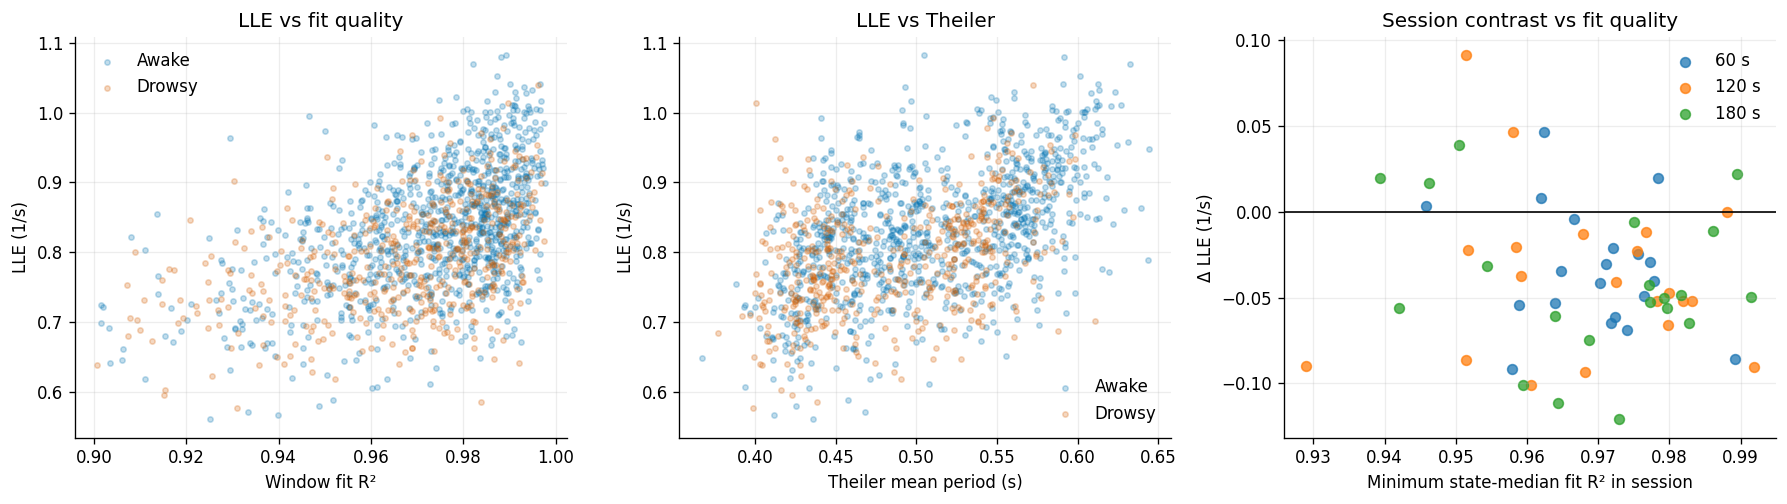

,value
fit_R2_min,0.900673
fit_R2_median,0.975948
fit_R2_max,0.997620
pair_support_min,1366.000000
theiler_s_min,0.366780
theiler_s_max,0.644376


,analysis,windows,paired_sessions,median_delta,ci_95_low,ci_95_high,p_value,rank_biserial,drowsy_lower,drowsy_higher
0,Primary R² >= 0.90,1508,20,-0.037570,-0.053698,-0.022976,0.000708,-0.809524,16,4
1,Sensitivity R² >= 0.95,1293,20,-0.030618,-0.041701,-0.013987,0.002325,-0.742857,16,4


In [8]:
# Cell 8 — QC Sensitivity
fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.3))
for state in STATE_ORDER:
    subset = analysis[analysis["state"] == state]
    axes[0].scatter(
        subset["fit_r2"], subset["lle_1_per_s"],
        s=10, alpha=0.24, color=COLORS[state], label=state,
    )
    axes[1].scatter(
        subset["theiler_s"], subset["lle_1_per_s"],
        s=10, alpha=0.24, color=COLORS[state], label=state,
    )

for duration_s in ALL_DURATIONS:
    subset = paired_contrasts[paired_contrasts["window_size_s"] == duration_s]
    axes[2].scatter(
        subset["session_fit_r2"], subset["delta"],
        s=34, alpha=0.75, label=f"{duration_s} s",
    )
axes[2].axhline(0.0, color="black", linewidth=1.0)
axes[0].set(xlabel="Window fit R²", ylabel="LLE (1/s)", title="LLE vs fit quality")
axes[1].set(xlabel="Theiler mean period (s)", ylabel="LLE (1/s)", title="LLE vs Theiler")
axes[2].set(
    xlabel="Minimum state-median fit R² in session",
    ylabel="Δ LLE (1/s)", title="Session contrast vs fit quality",
)
for ax in axes:
    ax.grid(alpha=0.22)
    ax.legend(frameon=False)
fig.tight_layout()
plt.show()

strict_analysis = analysis[analysis["fit_r2"] >= STRICT_R2_THRESHOLD].copy()
_, strict_contrasts = build_session_contrasts(strict_analysis)
strict_primary_pairs = strict_contrasts[
    strict_contrasts["window_size_s"] == PRIMARY_DURATION
]
strict_primary_result = analyze_session_deltas(
    strict_primary_pairs["delta"].to_numpy(), PRIMARY_DURATION
)
qc_sensitivity_table = pd.DataFrame([
    {
        "analysis": "Primary R² >= 0.90",
        "windows": len(analysis),
        **primary_result,
    },
    {
        "analysis": "Sensitivity R² >= 0.95",
        "windows": len(strict_analysis),
        **strict_primary_result,
    },
])
qc_range_table = pd.Series({
    "fit_R2_min": analysis["fit_r2"].min(),
    "fit_R2_median": analysis["fit_r2"].median(),
    "fit_R2_max": analysis["fit_r2"].max(),
    "pair_support_min": analysis["n_pairs_fit_min"].min(),
    "theiler_s_min": analysis["theiler_s"].min(),
    "theiler_s_max": analysis["theiler_s"].max(),
}, name="value").to_frame()
display(qc_range_table.round(6))
display(qc_sensitivity_table[[
    "analysis", "windows", "paired_sessions", "median_delta",
    "ci_95_low", "ci_95_high", "p_value", "rank_biserial",
    "drowsy_lower", "drowsy_higher",
]].round(6))

# Rosenstein LLE — Full Dataset Results

## Data integrity

- Sessions: **20**
- Upstream-included Processed windows: **1,544**
- Total valid Processed windows: **1,508**
- Valid counts at 60 / 120 / 180 s: **872 / 399 / 237**
- Valid Awake / Drowsy counts: **1,003 / 505**
- QC failures retained outside inference: **36**, all `low_fit_r2`
- Valid LLE range: **0.5614–1.0819 1/s**

## Primary result — 60 s

- Paired sessions: **20**
- Median of session-level Awake medians: **0.8109 1/s**
- Median of session-level Drowsy medians: **0.7947 1/s**
- Median Δ (Drowsy − Awake): **−0.03757 1/s**
- 95% session-bootstrap CI: **[−0.05370, −0.02298] 1/s**
- Wilcoxon signed-rank: **p = 0.000708**
- Matched-pairs rank-biserial correlation: **r_rb = −0.810**
- Sessions with Δ < 0: **16/20**; Δ > 0: **4/20**

## Window-size robustness

| Duration | Paired sessions | Median Δ | 95% CI | p | r_rb | Drowsy < Awake |
|---|---:|---:|---:|---:|---:|---:|
| 60 s | 20 | −0.03757 | [−0.05370, −0.02298] | 0.000708 | −0.810 | 16/20 |
| 120 s | 20 | −0.04421 | [−0.05910, −0.02161] | 0.002325 | −0.743 | 18/20 |
| 180 s | 20 | −0.04985 | [−0.05840, −0.02132] | 0.000586 | −0.819 | 16/20 |

Direction, magnitude, and CI are broadly consistent across window sizes. The 60-s result remains the sole primary inference; 120/180-s results are robustness evidence and are not treated as co-primary hypotheses.

## Cross-session replication

- Primary direction is replicated in **16/20 sessions**; four sessions show Drowsy > Awake.
- Across all available durations, **17/20 sessions** retain one sign and **3/20** show a sign reversal.
- Spearman consistency: `ρ=0.868` for 60 vs 120 s, `ρ=0.456` for 60 vs 180 s, and `ρ=0.582` for 120 vs 180 s.
- The effect is heterogeneous in magnitude, but negative median contrasts recur at every duration.

## QC robustness

- Valid-window fit R²: median **0.9760**, IQR **0.9610–0.9860**, range **0.9007–0.9976**.
- Minimum pair support in any retained fit: **1,366 pairs**.
- Theiler mean-period range: **0.3668–0.6444 s**.
- Requiring `R² >= 0.95` retains **1,293 windows** and all **20 primary paired sessions**: median Δ **−0.03062**, 95% CI **[−0.04170, −0.01399]**, `p=0.002325`, `r_rb=−0.743`, with **16/20** sessions negative.

## Conclusion

Primary interpretation:

> Drowsiness is associated with lower local trajectory divergence in reconstructed Processed PPG dynamics at the session level.

Evidence strength:

- session-level replication: strong but not universal;
- window-size robustness: consistent negative median effect at 60/120/180 s;
- effect-size consistency: large negative matched rank-biserial effects across durations;
- QC sensitivity: primary direction and inference persist under `R² >= 0.95`.

Scientific caution:

> Rosenstein LLE quantifies local trajectory divergence under the chosen reconstructed-state estimator. Positive LLE alone is not interpreted as proof of deterministic chaos.

## Next Step

`LLE surrogate testing → integration with Nonlinear Prediction + RQA`